<a href="https://colab.research.google.com/github/ALIA-HAIDER/CodeScope/blob/main/codeScope2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/MiniProject_CodeScope

features.pkl  logistic_model.pkl   scaler.pkl	  Train_data.zip
jm1.zip       power_transform.pkl  Test_data.zip  xg_model.pkl


In [ ]:
!cp /content/drive/MyDrive/MiniProject_CodeScope/jm1.zip /content/

In [ ]:
!unzip /content/jm1.zip

Archive:  /content/jm1.zip
replace jm1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!ls

bug_model.pkl  jm1.csv		   power_transform.pkl	xg_model.pkl
drive	       jm1.zip		   sample_data
features.pkl   logistic_model.pkl  scaler.pkl


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
train=pd.read_csv('jm1.csv')

In [ ]:
train.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            108

In [ ]:
train.isnull().sum()

,0
loc,0
v(g),0
ev(g),0
iv(g),0
n,0
v,0
l,0
d,0
i,0
e,0


Creating adiitional Target variable

In [ ]:
# 1 -> Complexity level
def complexity_level(x):
    if x < 5:
        return 0
    elif x < 10:
        return 1
    else:
        return 2

train["complexity_level"] = train["v(g)"].apply(complexity_level)


In [ ]:
# 2 -> Maintainability score
# 171 - 5.2 * ln(Halstead Volume) - 0.23 * Cyclomatic Complexity - 16.2 * ln(LOC)
train["maintainability_score"] = (
    171 - 5.2 * np.log(train["v"]) - 0.23 * train["v(g)"] - 16.2 * np.log(train["loc"])
)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# 3 -> Code Smell Risk
# High complexity + large LOC = smell
# train["code_smell_risk"] = ((train["v(g)"] > 10) & (train["loc"] > 200)).astype(int)

def smell_level(row):
    if row["v(g)"] > 12 or row["loc"] > 300:
        return 2   # High smell
    elif row["v(g)"] > 6 or row["loc"] > 150:
        return 1   # Medium
    else:
        return 0   # Low

train["code_smell_risk"] = train.apply(smell_level, axis=1)

In [ ]:
# 4 -> Technical Debt
# Technical debt = Cyclomatic Complexity + Halstead Effort * 0.001 + LOC
train["technical_debt"] = train["v(g)"] + train["e"] * 0.001 + train["loc"]


In [ ]:
derived_outputs = train[[
    "complexity_level",
    "maintainability_score",
    "code_smell_risk",
    "technical_debt"
]].copy()

In [ ]:
# Check new columns
print(train.columns)

Index(['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't',
       'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op',
       'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects',
       'complexity_level', 'maintainability_score', 'code_smell_risk',
       'technical_debt'],
      dtype='object')


In [ ]:
train['defects']=train['defects'].map({True:1 ,False:0})
cols_to_convert = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']

for col in cols_to_convert:
    train[col] = pd.to_numeric(train[col], errors='coerce')

correlation checking


In [ ]:
corr_matrix=train.corr().abs()
print(corr_matrix)

                            loc      v(g)     ev(g)     iv(g)         n  \
loc                    1.000000  0.817757  0.517551  0.784057  0.881795   
v(g)                   0.817757  1.000000  0.701710  0.859590  0.730781   
ev(g)                  0.517551  0.701710  1.000000  0.639574  0.465992   
iv(g)                  0.784057  0.859590  0.639574  1.000000  0.702415   
n                      0.881795  0.730781  0.465992  0.702415  1.000000   
v                      0.900293  0.759881  0.445902  0.743193  0.984276   
l                      0.286587  0.252902  0.233982  0.197736  0.240749   
d                      0.689543  0.669057  0.434009  0.575369  0.808113   
i                      0.499946  0.303031  0.213211  0.309717  0.651209   
e                      0.750564  0.709501  0.315538  0.757702  0.716536   
b                      0.899965  0.759635  0.445693  0.743013  0.983938   
t                      0.750564  0.709501  0.315538  0.757702  0.716536   
lOCode                 0.

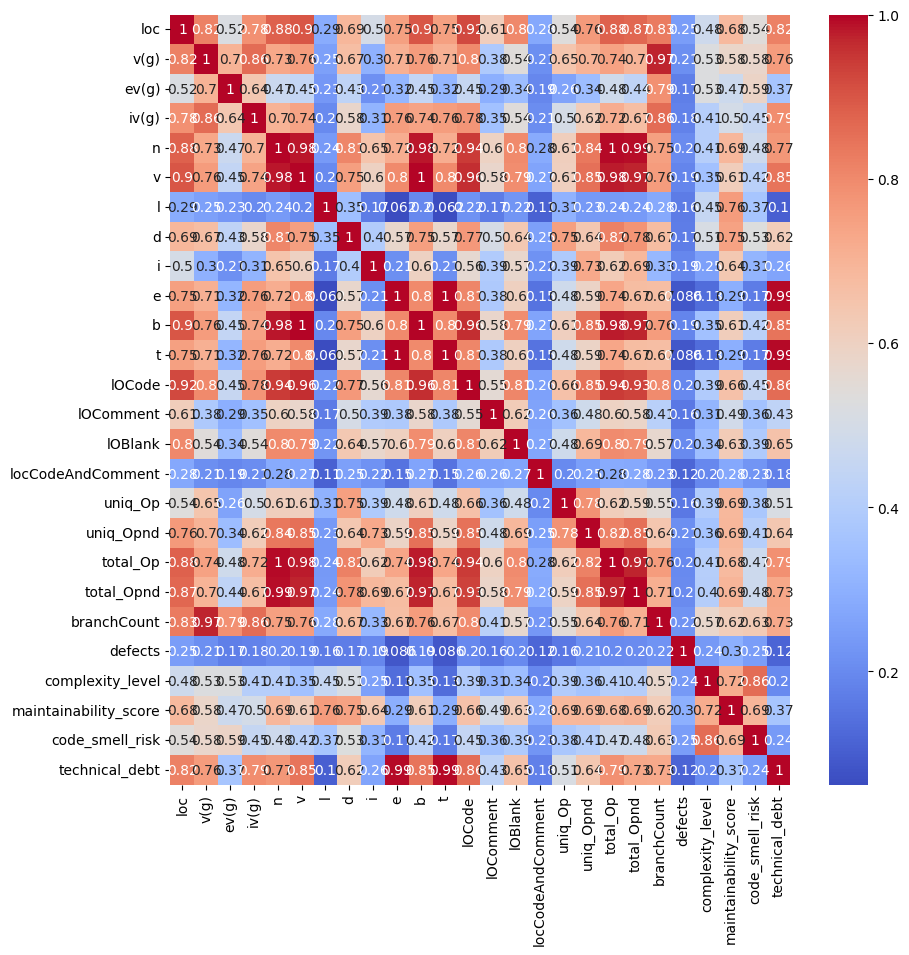

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.show()

In [ ]:
# removing highly correlated features as this correlation if feature to feature
upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
protected_columns=['complexity_level','maintainability_score','techincal_debt']


to_drop=[column for column in upper.columns if any(upper[column]>0.85) and column not in protected_columns]
train=train.drop(columns=to_drop)


In [ ]:
print(train.columns)

Index(['loc', 'v(g)', 'ev(g)', 'l', 'd', 'i', 'e', 'lOComment', 'lOBlank',
       'locCodeAndComment', 'uniq_Op', 'defects', 'complexity_level',
       'maintainability_score'],
      dtype='object')


Seperating Feature and Target

In [ ]:
from sklearn.model_selection import train_test_split

td=['complexity_level',
       'maintainability_score']
train=train.drop(columns=td,axis=1)

x=train.drop(columns=["defects"],axis=1)
y=train["defects"]

x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
# Replace infinity with NaN
x_train = x_train.replace([np.inf, -np.inf], np.nan)
x_val = x_val.replace([np.inf, -np.inf], np.nan)

# Fill NaN values (median works best for code metrics)
x_train = x_train.fillna(x_train.median())
x_val = x_val.fillna(x_train.median())

# For target
y_train = y_train.fillna(y_train.median())
y_val = y_val.fillna(y_train.median())

x_train_orig=x_train.copy()
x_val_orig=x_val.copy()

Normalize Data

In [ ]:
targets = [ 'maintainability_score']
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
features = [col for col in numeric_cols if col not in targets and col !='defects']

In [ ]:
skew_values = train[features].skew().sort_values(ascending=False)
print(skew_values)

e                    46.212151
locCodeAndComment    22.306581
v(g)                 15.218085
loc                  14.826236
uniq_Op              14.567006
lOBlank              13.553075
lOComment            11.394199
ev(g)                 8.185657
d                     6.017683
i                     5.152754
l                     1.920659
dtype: float64


In [ ]:
from sklearn.preprocessing import PowerTransformer, StandardScaler

x_train_bug = x_train_orig.copy()
x_val_bug = x_val_orig.copy()
y_train_bug = y_train.copy()
y_val_bug = y_val.copy()


# Yeo-johnson (handles skew)
pt = PowerTransformer(method='yeo-johnson')
x_train_bug[features] = pt.fit_transform(x_train_bug[features])
x_val_bug[features] = pt.transform(x_val_bug[features])


#  scale to mean=0, std=1
scaler = StandardScaler()
x_train_bug[features] = scaler.fit_transform(x_train_bug[features])
x_val_bug[features] = scaler.transform(x_val_bug[features])


In [ ]:
skew_values = x_train_bug[features].skew().sort_values(ascending=False)
print(skew_values)

locCodeAndComment    2.369605
ev(g)                0.852233
lOComment            0.833450
l                    0.340700
uniq_Op              0.183872
v(g)                 0.133417
lOBlank              0.087337
i                    0.042746
loc                  0.021888
d                   -0.020126
e                   -0.040295
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_bug=scaler.fit_transform(x_train_bug)
x_val_bug=scaler.transform(x_val_bug)


Model Training


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, r2_score

Bug Risk Model

In [ ]:
bug_model=RandomForestClassifier(
     n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

bug_model.fit(x_train_bug,y_train_bug)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
bug_prob = bug_model.predict_proba(x_val_bug)[:, 1]
bug_pred_from_prob = (bug_prob >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_val_bug, bug_pred_from_prob))
print(classification_report(y_val_bug, bug_pred_from_prob))

Accuracy: 0.8135048231511254
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1758
           1       0.54      0.23      0.32       419

    accuracy                           0.81      2177
   macro avg       0.69      0.59      0.61      2177
weighted avg       0.78      0.81      0.78      2177



In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(x_train_bug,y_train_bug)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
nug_reg=model.predict_proba(x_val_bug)[:,1]
nug_pred_from_prob = (nug_reg >= 0.5).astype(int)
print(nug_reg)
print(y_val_bug)
print("Bug Risk Accuracy:", accuracy_score(y_val_bug, nug_pred_from_prob))
print(classification_report(y_val_bug, nug_pred_from_prob))

[0.4749911  0.14712974 0.23317839 ... 0.43251849 0.46170212 0.2014822 ]
3133     0
5785     0
7458     0
8952     0
10240    0
        ..
6088     0
1963     1
5807     0
8560     0
5426     0
Name: defects, Length: 2177, dtype: int64
Bug Risk Accuracy: 0.6614607257694074
              precision    recall  f1-score   support

           0       0.90      0.65      0.76      1758
           1       0.33      0.71      0.45       419

    accuracy                           0.66      2177
   macro avg       0.61      0.68      0.60      2177
weighted avg       0.79      0.66      0.70      2177



In [ ]:
from xgboost import XGBClassifier

xg_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)
xg_model.fit(x_train_bug, y_train_bug)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
nug_xg=xg_model.predict(x_val_bug)
xg_prob = xg_model.predict_proba(x_val_bug)[:, 1]
print("Bug Risk Accuracy:", accuracy_score(y_val_bug, nug_xg))
print(classification_report(y_val_bug, nug_xg))
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_val_bug, nug_xg)
print("ROC-AUC:", auc)
from sklearn.metrics import average_precision_score

pr_score = average_precision_score(y_val_bug, bug_prob)
print("PR Score:", pr_score)

Bug Risk Accuracy: 0.7358750574184658
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1758
           1       0.37      0.52      0.43       419

    accuracy                           0.74      2177
   macro avg       0.62      0.65      0.63      2177
weighted avg       0.78      0.74      0.75      2177

ROC-AUC: 0.6537723220952427
PR Score: 0.4234654972718727


In [ ]:
log_percent = nug_reg * 100
xg_percent = xg_prob * 100

In [ ]:
import joblib

joblib.dump(bug_model, "bug_model.pkl")
joblib.dump(xg_model, "xg_model.pkl")
joblib.dump(model, "logistic_model.pkl")

['logistic_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pt, "power_transform.pkl")
joblib.dump(features, "features.pkl")

['features.pkl']

In [ ]:
loaded_model = joblib.load("bug_model.pkl")
print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
final_output = pd.DataFrame({
    "bug_risk_log_%": log_percent ,
    "bug_risk_xg_%": xg_percent ,
    "bug_binary_%":nug_xg,
    "bug_prob_mean_%":(log_percent+xg_percent)/2,
    "complexity_level": derived_outputs.loc[x_val.index, "complexity_level"],
    "code_smell_risk": derived_outputs.loc[x_val.index, "code_smell_risk"],
    "maintainability_score": derived_outputs.loc[x_val.index, "maintainability_score"],
    "technical_debt": derived_outputs.loc[x_val.index, "technical_debt"]
})

In [ ]:
print(final_output)

       bug_risk_log_%  bug_risk_xg_%  bug_binary_%  bug_prob_mean_%  \
3133        47.499110      26.801815             0        37.150462   
5785        14.712974      15.428041             0        15.070507   
7458        23.317839      16.616285             0        19.967062   
8952        12.356301       4.154966             0         8.255633   
10240       56.104708      48.817932             0        52.461320   
...               ...            ...           ...              ...   
6088        46.904808      46.579765             0        46.742287   
1963        65.638094      72.530975             1        69.084535   
5807        43.251849      26.417850             0        34.834850   
8560        46.170212      72.537872             1        59.354042   
5426        20.148220      44.121803             0        32.135012   

       complexity_level  code_smell_risk  maintainability_score  \
3133                  0                0              97.676689   
5785         

In [ ]:
# Complexity Level
final_output["complexity_level"] = final_output["complexity_level"].apply(
    lambda x: "Low" if x == 0 else ("Medium" if x == 1 else "High")
)

# Code Smell Risk
final_output["code_smell_risk"] = final_output["code_smell_risk"].apply(
    lambda x: "Low" if x == 0 else "High"
)

# Maintainability Score
final_output["maintainability_score"] = final_output["maintainability_score"].apply(
    lambda x: "High" if x > 85 else ("Medium" if x > 65 else "Low")
)

# Technical Debt (using quantiles)
q1 = final_output["technical_debt"].quantile(0.33)
q2 = final_output["technical_debt"].quantile(0.66)

final_output["technical_debt"] = final_output["technical_debt"].apply(
    lambda x: "Low" if x <= q1 else ("Medium" if x <= q2 else "High")
)

In [ ]:
print(final_output)

       bug_risk_log_%  bug_risk_xg_%  bug_binary_%  bug_prob_mean_%  \
3133        47.499110      26.801815             0        37.150462   
5785        14.712974      15.428041             0        15.070507   
7458        23.317839      16.616285             0        19.967062   
8952        12.356301       4.154966             0         8.255633   
10240       56.104708      48.817932             0        52.461320   
...               ...            ...           ...              ...   
6088        46.904808      46.579765             0        46.742287   
1963        65.638094      72.530975             1        69.084535   
5807        43.251849      26.417850             0        34.834850   
8560        46.170212      72.537872             1        59.354042   
5426        20.148220      44.121803             0        32.135012   

      complexity_level code_smell_risk maintainability_score technical_debt  
3133               Low             Low                  High         

In [ ]:
def predict_and_collect(input_data):
    import pandas as pd
    import numpy as np

    # Create full feature row
    df = pd.DataFrame(columns=x_train.columns)
    df.loc[0] = x_train.median()

    for key in input_data:
        if key in df.columns:
            df.at[0, key] = input_data[key]

    # ---- Preprocessing (ONLY ONCE) ----
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(x_train.median())

    df[features] = pt.transform(df[features])
    df[features] = scaler.transform(df[features])

    # ---- Predictions ----
    log_prob = model.predict_proba(df)[:,1][0]
    xg_prob = xg_model.predict_proba(df)[:,1][0]

    log_percent = log_prob * 100
    xg_percent = xg_prob * 100
    avg_prob = (log_percent + xg_percent) / 2
    bug_binary = int(xg_prob >= 0.5)

    # ---- Safe input extraction ----
    v_g = input_data.get("v(g)", 0)
    loc = input_data.get("loc", 0)
    v = input_data.get("v", 1)
    e = input_data.get("e", 0)

    # ---- Derived Outputs ----
    complexity = "Low" if v_g < 5 else ("Medium" if v_g < 10 else "High")

    maintainability = (
        171 - 5.2*np.log(v+1) - 0.23*v_g - 16.2*np.log(loc+1)
    )
    maintainability_label = (
        "High" if maintainability > 85 else ("Medium" if maintainability > 65 else "Low")
    )

    if v_g > 12 or loc > 300:
        smell = "High"
    elif v_g > 6 or loc > 150:
        smell = "Medium"
    else:
        smell = "Low"

    debt = v_g + e*0.001 + loc
    if debt < 50:
        debt_label = "Low"
    elif debt < 150:
        debt_label = "Medium"
    else:
        debt_label = "High"

    # ---- Final Output ----
    result = {
    "bug_risk_log_%": float(round(log_percent, 2)),
    "bug_risk_xg_%": float(round(xg_percent, 2)),
    "bug_binary": int(bug_binary),
    "bug_prob_mean_%": float(round(avg_prob, 2)),
    "complexity_level": complexity,
    "code_smell_risk": smell,
    "maintainability_score": maintainability_label,
    "technical_debt": debt_label
}

    return result

In [ ]:
input_data = {
    "v(g)": 8,
    "loc": 120,
    "v": 300,
    "e": 5000,
    "uniq_Op": 20,
    "uniq_Opnd": 15,
    "total_Op": 100,
    "total_Opnd": 80,
    "branchCount": 10
}

output = predict_and_collect(input_data)
print(output)

{'bug_risk_log_%': 85.77, 'bug_risk_xg_%': 55.11000061035156, 'bug_binary': 1, 'bug_prob_mean_%': 70.44, 'complexity_level': 'Medium', 'code_smell_risk': 'Medium', 'maintainability_score': 'Low', 'technical_debt': 'Medium'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
from google.colab import files

files.download("bug_model.pkl")
files.download("xg_model.pkl")
files.download("logistic_model.pkl")
files.download("scaler.pkl")
files.download("power_transform.pkl")
files.download("features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>